In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("Raw-sales-data.csv", encoding="ISO-8859-1")

In [6]:
pd.set_option("display.max_columns", None)

In [7]:
reduced_df = df[["Document Date", "Document Type", "Item Class", "Quantity", "Sales", "Profit"]]

In [8]:
df.head(1)

,Invoice To Code,Invoice To Name,Sold To Code,Sold To Name,Document Number,Document Date,Document Fin Period,Document Type,Tax Code,Order Number,Customer Order Number,Order Date,Delivery Days,Planned Delivery Date,Item Class,Product Family,Item Number,Item Description,Sales Person,Supply Group,Quantity,Sales,Cost,Profit,Profit Percentage,Account,Delivery Line 1,Delivery Line 2,Delivery Line 3,Delivery Line 4,Delivery Line 5,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37
0,001BT,BLOEM TECH (PTY) LTD,001BT,BLOEM TECH (PTY) LTD,INV-163657,4/30/2021,Apr-21,INVOICE,01A,SO-065395,QT-015097,4/28/2021,0.0,5/26/2021,SP,SP » SPARES,9927520010,PL.PR.FLUOR.TUBE COVER 1300MM,HOPE MHLONGO,NaN,6,410.7,10.98,399.72,97.3,2000020 CS » Sales-Spare Parts-Third Party,1 WATERMEYER STREET,HILTON,BLOEMFONTEIN,FREE STATE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
reduced_df.head(2)

,Document Date,Document Type,Item Class,Quantity,Sales,Profit
0,4/30/2021,INVOICE,SP,6,410.7,399.72
1,4/30/2021,INVOICE,SP,12,58.08,29.54


Filtering the data.

In [10]:
filtered_df = reduced_df[reduced_df["Document Type"] == "INVOICE"]

Converting the date column to datetime.

In [11]:
filtered_df.loc[:, "Document Date"] = pd.to_datetime(filtered_df["Document Date"])

Dropping all the 

In [12]:
filtered_df = filtered_df.dropna(subset=["Document Date"])
filtered_df = filtered_df.dropna(subset=["Quantity"])

Sorting the data

In [13]:
filtered_df["Quantity"] = pd.to_numeric(filtered_df["Quantity"], errors="coerce")

In [14]:
filtered_df = filtered_df.sort_values(by="Document Date", ascending=True)

In [15]:
filtered_df = filtered_df.reset_index(drop=True)

Grouping the data by months

In [16]:
filtered_df["Document Date"] = pd.to_datetime(filtered_df["Document Date"])
filtered_df["YearMonth"] = filtered_df["Document Date"].dt.to_period("M")
monthly_sales = filtered_df.groupby("YearMonth")["Quantity"].sum().reset_index()
excel = monthly_sales.to_csv("shsdhdhdhdh_gouped.csv")
excel = monthly_sales.to_csv("shsdhdhdhdh_ungouped.csv")

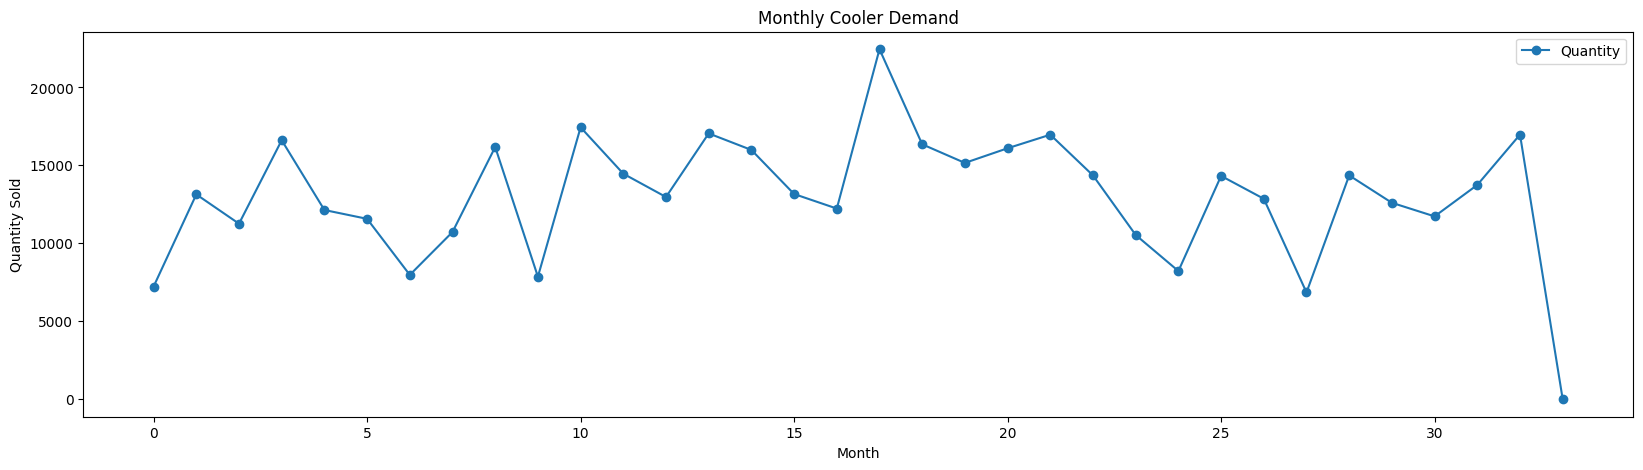

In [17]:
monthly_sales.plot(kind="line", marker="o", title="Monthly Cooler Demand", figsize=(20, 5))
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.show()

Prophet

In [18]:
from prophet import Prophet

C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
model = Prophet()

In [20]:
prophet_df = filtered_df[["Document Date", "Quantity"]]

In [21]:
prophet_df.columns = ["ds", "y"]

In [22]:
prophet_df = prophet_df.dropna(subset=["ds", "y"])

In [23]:
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"], errors="coerce")

Fitting the values into the model

In [24]:
model.fit(prophet_df)

13:19:29 - cmdstanpy - INFO - Chain [1] start processing
13:19:29 - cmdstanpy - INFO - Chain [1] done processing


Making Future Dates in Prophet

In [25]:
future_dates = model.make_future_dataframe(periods=365)

In [26]:
predictions = model.predict(future_dates)

In [27]:
predictions.head(10)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-05,38.333092,-105.328065,157.520638,38.333092,38.333092,-13.843000,-13.843000,-13.843000,0.108707,0.108707,0.108707,-13.951707,-13.951707,-13.951707,0.0,0.0,0.0,24.490092
1,2021-01-13,38.449605,-92.710256,162.229081,38.449605,38.449605,-5.000333,-5.000333,-5.000333,-3.735043,-3.735043,-3.735043,-1.265290,-1.265290,-1.265290,0.0,0.0,0.0,33.449272
2,2021-01-14,38.464170,-87.838556,159.210346,38.464170,38.464170,-7.420851,-7.420851,-7.420851,-7.455830,-7.455830,-7.455830,0.034979,0.034979,0.034979,0.0,0.0,0.0,31.043319
3,2021-01-15,38.478734,-91.510919,163.963034,38.478734,38.478734,-5.809839,-5.809839,-5.809839,-6.995424,-6.995424,-6.995424,1.185585,1.185585,1.185585,0.0,0.0,0.0,32.668895
4,2021-01-18,38.522426,-81.191888,165.841664,38.522426,38.522426,-3.345847,-3.345847,-3.345847,-6.948682,-6.948682,-6.948682,3.602835,3.602835,3.602835,0.0,0.0,0.0,35.176579
5,2021-01-19,38.536990,-76.909001,173.566700,38.536990,38.536990,4.150233,4.150233,4.150233,0.108707,0.108707,0.108707,4.041526,4.041526,4.041526,0.0,0.0,0.0,42.687223
6,2021-01-20,38.551555,-76.909279,160.330603,38.551555,38.551555,0.562318,0.562318,0.562318,-3.735043,-3.735043,-3.735043,4.297361,4.297361,4.297361,0.0,0.0,0.0,39.113872
7,2021-01-21,38.566119,-88.168596,162.906973,38.566119,38.566119,-3.078299,-3.078299,-3.078299,-7.455830,-7.455830,-7.455830,4.377532,4.377532,4.377532,0.0,0.0,0.0,35.487820
8,2021-01-22,38.580683,-83.761706,157.828251,38.580683,38.580683,-2.702069,-2.702069,-2.702069,-6.995424,-6.995424,-6.995424,4.293355,4.293355,4.293355,0.0,0.0,0.0,35.878614
9,2021-01-25,38.624375,-90.250972,157.709460,38.624375,38.624375,-3.728508,-3.728508,-3.728508,-6.948682,-6.948682,-6.948682,3.220174,3.220174,3.220174,0.0,0.0,0.0,34.895867


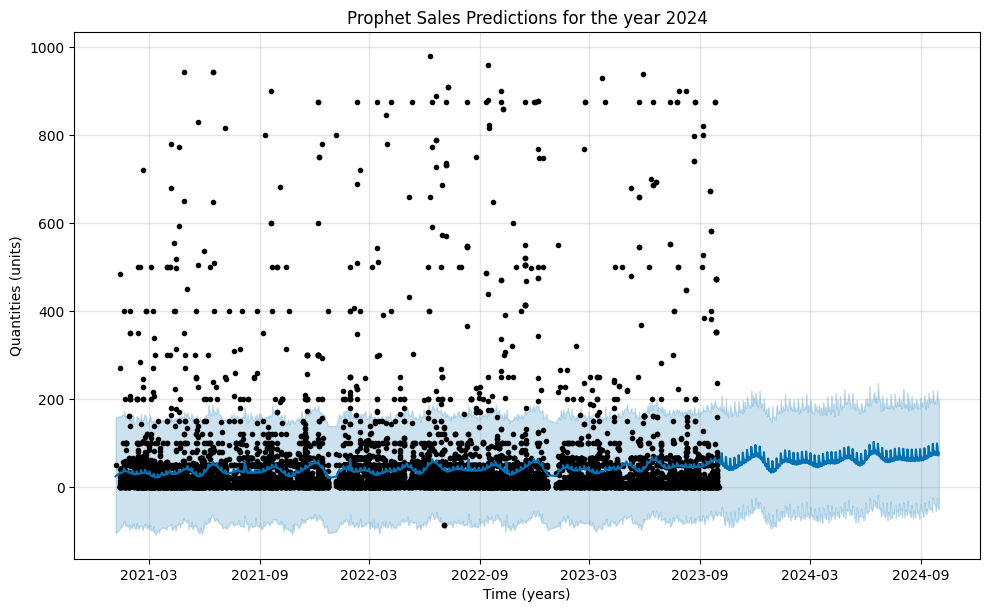

In [28]:
model.plot(predictions)
plt.title("Prophet Sales Predictions for the year 2024")
plt.xlabel("Time (years)")
plt.ylabel("Quantities (units)")
plt.show()

Transferring the model predictions to a csv file

In [39]:
predictions.to_csv("Prophet_Forecast_Results.csv", index=False)

Visualize each component

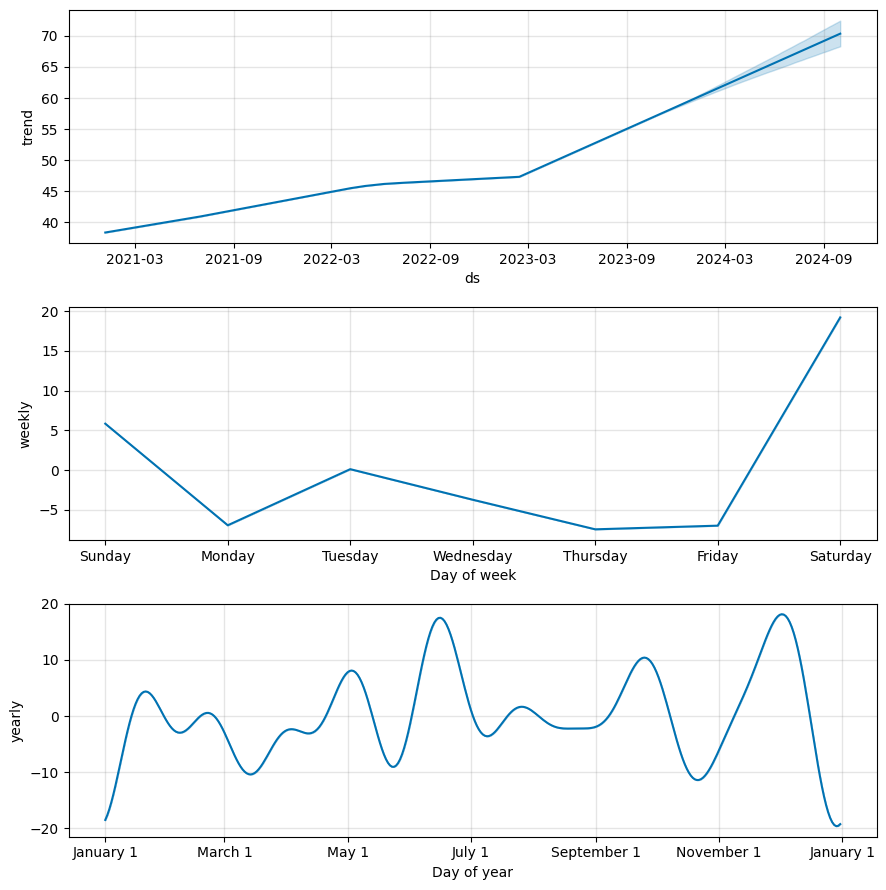

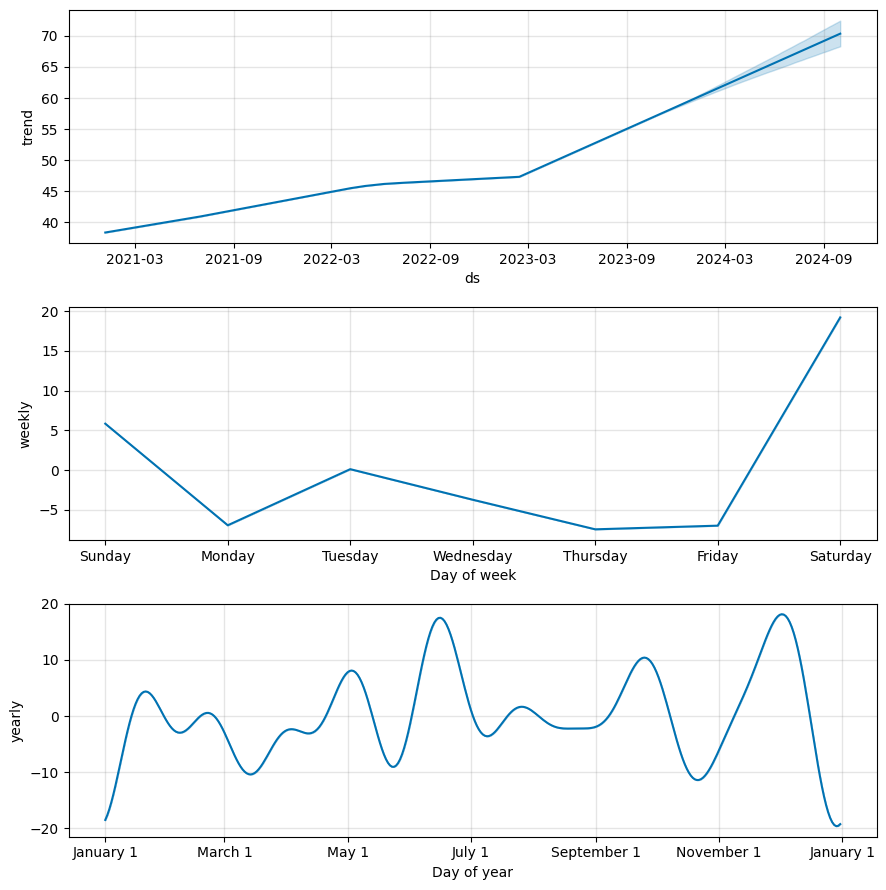

In [30]:
model.plot_components(predictions)

Cross Validation

In [31]:
from prophet.diagnostics import cross_validation

In [32]:
df_cv = cross_validation(model, initial='730 days', period='90 days', horizon='180 days')

  0%|                                                                     | 0/2 [00:00<?, ?it/s]13:19:32 - cmdstanpy - INFO - Chain [1] start processing
13:19:33 - cmdstanpy - INFO - Chain [1] done processing
 50%|██████████████████████████████▌                              | 1/2 [00:01<00:01,  1.95s/it]13:19:34 - cmdstanpy - INFO - Chain [1] start processing
13:19:35 - cmdstanpy - INFO - Chain [1] done processing
100%|█████████████████████████████████████████████████████████████| 2/2 [00:04<00:00,  2.25s/it]


In [33]:
from prophet.diagnostics import performance_metrics

In [34]:
df_P = performance_metrics(df_cv)

In [35]:
df_P.head(5)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,25 days,4591.793949,67.762777,39.692965,11.545341,1.707907,1.050337,0.950769
1,26 days,3683.295021,60.690156,37.454517,11.983646,1.887423,1.038540,0.956923
2,27 days,3546.625736,59.553554,37.029267,11.939426,1.887423,1.031046,0.961183
3,28 days,3242.444515,56.942467,36.244608,12.011872,2.396154,1.040661,0.966316
4,29 days,3015.027536,54.909266,35.996161,12.315301,2.396154,1.037917,0.967530


In [36]:
df_P.tail(10)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
120,169 days,20914.195393,144.617410,69.911538,17.658740,5.153550,1.279200,0.941538
121,170 days,20905.079548,144.585890,69.783089,17.867334,5.153550,1.281746,0.941538
122,172 days,20895.773582,144.553705,69.440081,17.639996,5.153550,1.268568,0.941538
123,173 days,20924.605214,144.653397,69.791129,17.840598,5.286166,1.277919,0.941538
124,174 days,24236.674612,155.681324,73.724238,17.542174,5.607408,1.293595,0.939005
125,175 days,22865.191892,151.212407,74.678565,16.576422,4.234199,1.246936,0.921499
126,176 days,22646.637336,150.487997,74.428479,17.144214,4.029136,1.246581,0.923077
127,177 days,19834.338085,140.834435,68.945721,16.926360,3.604657,1.214886,0.929312
128,179 days,19583.685787,139.941723,68.318580,16.791574,3.524774,1.206393,0.929798
129,180 days,18753.381450,136.942986,67.035398,16.886771,3.867754,1.212550,0.931498


Plotting the cross validation metrics RMSE

In [37]:
from prophet.plot import plot_cross_validation_metric

C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
C:\Users\GIBSON MZIMANDE\AppData\Local\Programs\Python\Python312\Lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


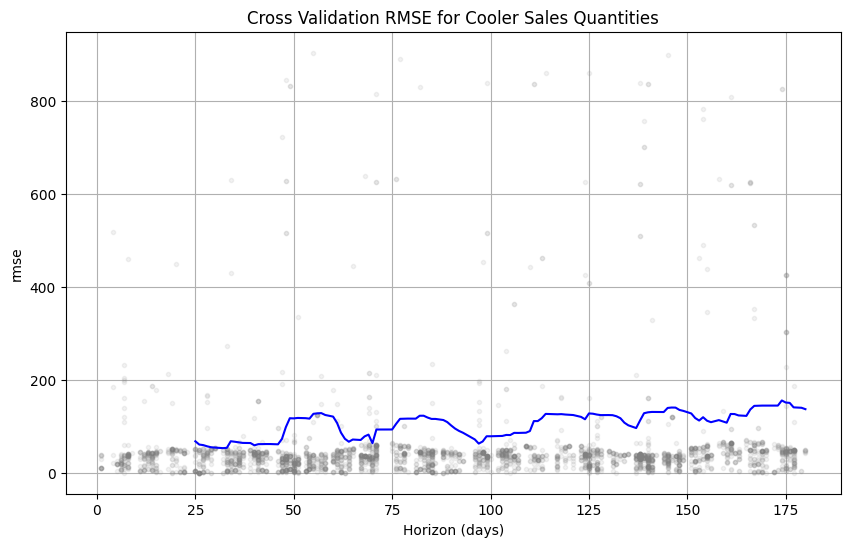

In [38]:
fig = plot_cross_validation_metric(df_cv, metric='rmse')

plt.title("Cross Validation RMSE for Cooler Sales Quantities")
plt.show()